In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Carga (usando el path de kagglehub)
df = pd.read_csv(f"{path}/IMDB Dataset.csv")

# Configuración
max_words = 10000
max_len = 200

# Tokenización y Padding
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['review'])
sequences = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(sequences, maxlen=max_len)

# Codificación de etiquetas (positive/negative -> 1/0)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
reverse_word_index = dict([(value, key) for (key, value) in tokenizer.word_index.items()])
#El Index es un identificador numérico único asignado a cada palabra única dentro del vocabulario (creado por el Tokenizer).
#Las computadoras no procesan texto directamente, por lo que el word_index crea un "mapeo" (ejemplo: "movie" -> 1, "bad" -> 2).
#En la fase de preparación, el texto se convierte en una lista de estos índices numéricos antes de pasar a la capa de Embedding.
#El índice es simplemente la "dirección" de la palabra en el diccionario del modelo.

def decode_review(text_sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in text_sequence])

print(f"Reseña original decodificada: \n{decode_review(X_train[0])}")

Reseña original decodificada: 
snow ian brown and now i'm a bit of a music fan and i'm familiar with most of these artists output but i didn't recognise any of the tracks during this movie apart from the run b sides anyone we get many many musical which how we're suppose to feel these are accompanied by such original images as couples kissing by a lake and in this is a problem as none of the songs convey the mood and we realise the director lacks the ability to carry the emotional journey to the audience through storytelling and dialogue alone br br the ending is presumably meant to be just as everybody gets their and there is at least one big shock in store but i remained because the script had given me no one to root for it's not enough to tackle a hot button issue you have to actually give us a plot that hasn't already been done to death and individuals who are more than window dressing as it stands this film is a noble failure with only the promising lead actress and a few mildly p

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
    #El Embedding es una técnica de representación de palabras donde palabras con significados similares tienen una representación numérica similar.
    #A diferencia de un simple índice numérico, el embedding convierte cada palabra en un vector de números reales (en este caso, de tamaño 128).
    #Esto permite que la red neuronal "entienda" relaciones semánticas entre palabras (por ejemplo, que "excelente" y "buena" tienen una carga emocional similar)
    #basándose en su posición en un espacio vectorial multidimensional.
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
#Una Epoch o Época representa un paso completo por todo el conjunto de datos de entrenamiento. Si configuras 5 épocas, el modelo verá cada una de las 50,000 reseñas del dataset de IMDB cinco veces.
#En cada época, los pesos de la red neuronal se ajustan mediante el error calculado para mejorar la precisión en la siguiente pasada. Es el ciclo de aprendizaje completo del modelo.

Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 108s 187ms/step - accuracy: 0.7960 - loss: 0.4469 - val_accuracy: 0.8403 - val_loss: 0.3762
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 140s 184ms/step - accuracy: 0.8524 - loss: 0.3514 - val_accuracy: 0.8690 - val_loss: 0.3241
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 182ms/step - accuracy: 0.8818 - loss: 0.2931 - val_accuracy: 0.8685 - val_loss: 0.3350
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 143s 184ms/step - accuracy: 0.9026 - loss: 0.2468 - val_accuracy: 0.8763 - val_loss: 0.3287
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 102s 181ms/step - accuracy: 0.9217 - loss: 0.2031 - val_accuracy: 0.8758 - val_loss: 0.3457


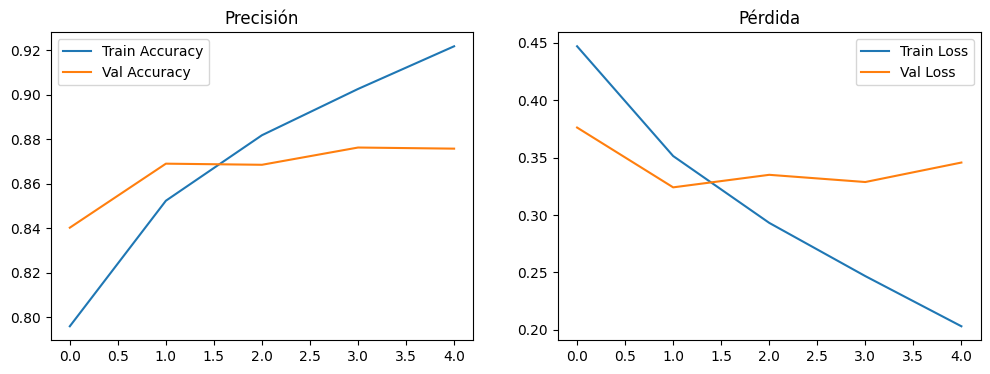

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida')
plt.legend()
plt.show()

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss en Test: {loss:.4f}")
print(f"Accuracy en Test: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8764 - loss: 0.3349
Loss en Test: 0.3349
Accuracy en Test: 0.8764


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss en Test: {loss:.4f}")
print(f"Accuracy en Test: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8764 - loss: 0.3349
Loss en Test: 0.3349
Accuracy en Test: 0.8764


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


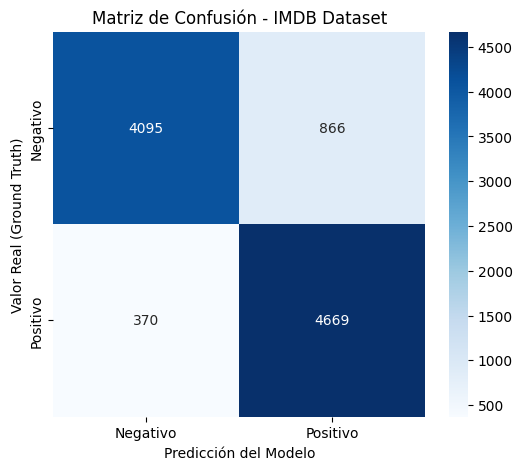

In [10]:
# 7. Matriz de Confusión (Corregido)
from sklearn.metrics import confusion_matrix
import seaborn as sns  # Importación independiente
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusión - IMDB Dataset')
plt.show()

In [15]:
#La matriz de confusion indica lo sgte
#4669 aciertos en lo que respecta a los valores positivos reales.
#4095 aciertos en lo que respecta a los valores negativos reales.
#866 falsos positivos
#370 falsos negativos


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


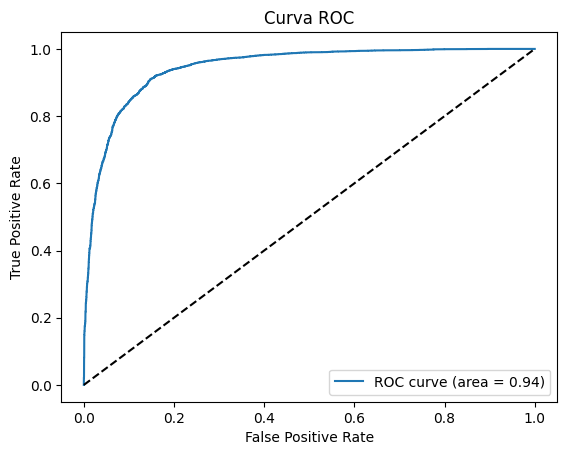

In [11]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

In [12]:
def predict_new_review(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prediction = model.predict(padded)
    sentiment = "Positiva" if prediction[0][0] > 0.5 else "Negativa"
    return sentiment, prediction[0][0]

# Ejemplo:
review_example = "The movie was absolutely fantastic! Great acting and story."
print(predict_new_review(review_example))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
('Positiva', np.float32(0.9384672))
